# Regex in pandas

Everything we did with `re` on a single string, pandas can do to a whole column through the `.str` accessor. That is where regular expressions pay off in data work: one pattern cleans, splits, or recodes thousands of rows at once. This page walks through the main `.str` regex methods and then puts them to work on a real dataset of restaurant inspections.

In [1]:
import pandas as pd
import re

## Finding every match with `.str.findall`

`.str.findall` runs `re.findall` on each row and returns a Series of lists. Here is a column of strings, some of which contain SSNs.

In [2]:
df_ssn = pd.DataFrame(
    ["987-65-4321", "forty", "123-45-6789 or 321-45-6789", "999-99-9999"],
    columns=["SSN"],
)

pattern = r"[0-9]{3}-[0-9]{2}-[0-9]{4}"
df_ssn["SSN"].str.findall(pattern)

0                 [987-65-4321]
1                            []
2    [123-45-6789, 321-45-6789]
3                 [999-99-9999]
Name: SSN, dtype: object

## Pulling fields apart with `.str.extract`

When a pattern has capture groups, `.str.extract` gives back a DataFrame with one column per group, keeping only the first match in each row. This turns a single messy column into tidy fields.

In [3]:
pattern_groups = r"([0-9]{3})-([0-9]{2})-([0-9]{4})"
df_ssn["SSN"].str.extract(pattern_groups)

,0,1,2
0,987,65,4321
1,NaN,NaN,NaN
2,123,45,6789
3,999,99,9999


If a row has several matches and you want all of them, `.str.extractall` returns one row per match, indexed by the original row and a match number.

In [4]:
df_ssn["SSN"].str.extractall(pattern_groups)

0   1     2
  match               
0 0      987  65  4321
2 0      123  45  6789
  1      321  45  6789
3 0      999  99  9999

## Canonicalizing with `.str.replace`

Back in the first section we canonicalized by chaining fixed `.str.replace` calls. With `regex=True`, a single replace can strip a whole family of substrings. This pattern removes any HTML tag, that is, a `<`, then anything that is not a `>`, then a `>`.

In [5]:
df_html = pd.DataFrame(
    ["<div><td>Moo</td></div>", '<a href="x">Link</a>', "<b>Bold</b>"],
    columns=["html"],
)

df_html["html"].str.replace(r"<[^>]+>", "", regex=True)

0     Moo
1    Link
2    Bold
Name: html, dtype: object

## Case study: restaurant inspections

Let's bring this together on real data. San Francisco publishes the results of its restaurant health inspections: a score for each inspection, plus free-text descriptions of every violation found. The descriptions are written by inspectors, so they are inconsistent. Our question:

> How do inspection scores vary with the number of violations that mention a particular kind of problem, like vermin or unclean surfaces?

To answer it we first have to wrangle the violation text into something countable.

In [6]:
vio = pd.read_csv("data/violations.csv", header=0, names=["bid", "date", "desc"])
vio.head()

,bid,date,desc
0,19,20171211,Inadequate food safety knowledge or lack of ce...
1,19,20171211,Unapproved or unmaintained equipment or utensils
2,19,20160513,Unapproved or unmaintained equipment or utensi...
3,19,20160513,Unclean or degraded floors walls or ceilings ...
4,19,20160513,Food safety certificate or food handler card n...


Each description often carries an extra note in square brackets, like `[ date violation corrected ]`, which makes otherwise identical violations look different. Counting the raw descriptions shows how much variety that creates.

In [7]:
vio["desc"].value_counts().shape

(14253,)

We canonicalize: a regex strips the trailing bracketed note, then we trim whitespace and lowercase. The number of distinct descriptions drops sharply.

In [8]:
vio["clean_desc"] = (
    vio["desc"]
    .str.replace(r"\s*\[.*\]$", "", regex=True)
    .str.strip()
    .str.lower()
)
vio["clean_desc"].value_counts().shape

(68,)

Now we turn keywords into features. `.str.contains` takes a regex, and the `|` metacharacter means "or," so `clean|sanit` flags any description mentioning cleaning or sanitation. We build one boolean column per kind of problem.

In [9]:
with_features = vio.assign(
    is_unclean=vio["clean_desc"].str.contains("clean|sanit"),
    is_high_risk=vio["clean_desc"].str.contains("high risk"),
    is_vermin=vio["clean_desc"].str.contains("vermin"),
    is_surface=vio["clean_desc"].str.contains("wall|ceiling|floor|surface"),
    is_human=vio["clean_desc"].str.contains("hand|glove|hair|nail"),
    is_permit=vio["clean_desc"].str.contains("permit|certif"),
)
with_features.head()

,bid,date,desc,clean_desc,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
0,19,20171211,Inadequate food safety knowledge or lack of ce...,inadequate food safety knowledge or lack of ce...,False,False,False,False,False,True
1,19,20171211,Unapproved or unmaintained equipment or utensils,unapproved or unmaintained equipment or utensils,False,False,False,False,False,False
2,19,20160513,Unapproved or unmaintained equipment or utensi...,unapproved or unmaintained equipment or utensils,False,False,False,False,False,False
3,19,20160513,Unclean or degraded floors walls or ceilings ...,unclean or degraded floors walls or ceilings,True,False,False,True,False,False
4,19,20160513,Food safety certificate or food handler card n...,food safety certificate or food handler card n...,False,False,False,False,True,True


The text wrangling is done. The rest is analysis you have already seen: group to count each kind of violation per inspection, reshape to a tidy table, and join in the scores.

In [10]:
feature_cols = [
    "is_unclean", "is_high_risk", "is_vermin",
    "is_surface", "is_human", "is_permit",
]
counts = (
    with_features.groupby(["bid", "date"])[feature_cols].sum().reset_index()
)

tidy = counts.melt(
    id_vars=["bid", "date"], var_name="feature", value_name="num_vios"
)

scores = pd.read_csv(
    "data/inspections.csv", header=0, usecols=[0, 1, 2],
    names=["bid", "score", "date"],
)
combined = tidy.merge(scores, on=["bid", "date"])
combined.head()

,bid,date,feature,num_vios,score
0,19,20160513,is_unclean,1,94
1,19,20171211,is_unclean,0,94
2,24,20160311,is_unclean,2,96
3,24,20161005,is_unclean,1,98
4,24,20171101,is_unclean,0,98


Plotting score against the number of violations for each keyword shows the payoff. Scores drift down as violations pile up, and some keywords drag the score down faster than others. Read the plot for the trend; the plotting syntax is the subject of the visualization chapters.

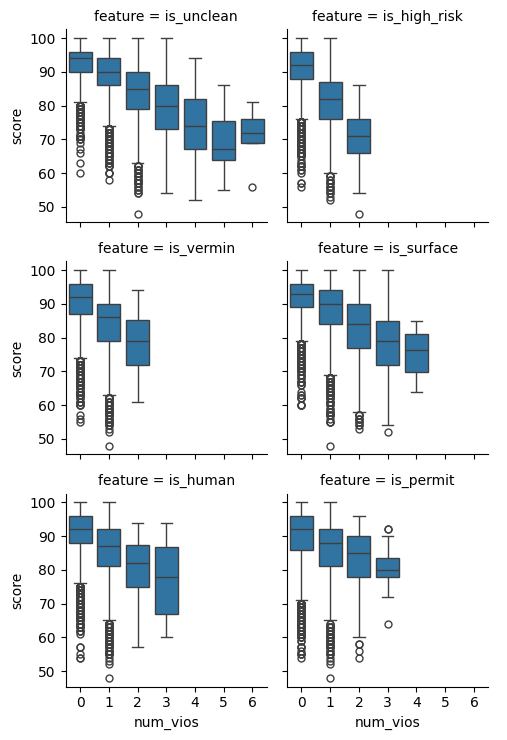

In [11]:
import seaborn as sns

sns.catplot(
    data=combined, x="num_vios", y="score",
    col="feature", col_wrap=2, kind="box", height=2.5,
);

:::{note} Takeaways
- `.str.findall`, `.str.extract`, and `.str.extractall` apply a regex to a whole column and return matches or capture groups.
- `.str.replace(..., regex=True)` canonicalizes in bulk; `.str.contains` with `|` turns keywords into features.
- On real data, regex-based wrangling is the step that makes messy text countable, which is what lets the analysis happen at all.
:::